In [1]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from functions import preprocess, export_weights, export_matrix_to_mem

In [ ]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from functions import preprocess, export_weights, export_matrix_to_mem

# Importação e processamento do Dataset

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

"Caution-possible spoilers ahead\x85.. Just watched 'Joe' for the second time. The first time was 30+ years ago on an Air Force Base. I was reminded of that by the Air Force overcoat with Tech. Sgt. stripes wore by the boyfriend/dealer; we airmen had quite a laugh the first time that appeared on the screen because that is a 'lifer' rank. Over the years I have carried several other images from the film. Foremost was the absolutely beautiful and vulnerable daughter of the executive. As someone else commented, you could not take you eyes off her. I did not realize until now that this was a 20-year old Susan Sarandon in her first movie. What a loss that she did not do more movies when she looked like that. I also recall the irony of having a counterculture hero like Peter Boyle playing the title role of a right-wing gun nut. Not unlike George C. Scott playing generals in Dr. Strangelove and Patton. And of course the shocking ending made a lasting impression.<br /><br />30+ years ago it was

In [5]:
print(preprocess(df.iloc[random_num]['review']))

caution possible spoiler ahead watched joe second time first time year ago air force base reminded air force overcoat tech sgt stripe wore boyfriend dealer airman quite laugh first time appeared screen lifer rank year carried several image film foremost absolutely beautiful vulnerable daughter executive someone else commented could take eye realize year old susan sarandon first movie loss movie looked like also recall irony counterculture hero like peter boyle playing title role right wing gun nut unlike george scott playing general strangelove patton course shocking ending made lasting impression year ago talked movie ever played base thought great film reluctant see afraid would disappointingly dated easy rider watching today amazed well film held strong script hole although wonder boyfriend immediately getting bathtub sarandon get searching explanation film still entertaining think something perfect physical casting boyle physically believable joe others pointed portrayal would insp

In [6]:
df['review'] = df['review'].apply(preprocess)

In [7]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [8]:
n_words = [len(i.split(" ")) for i in df['review']]
print(f"Quantidade média de tokens {np.mean(n_words)}")
print(f"Mediana de tokens {np.median(n_words)}")

Quantidade média de tokens 116.49538
Mediana de tokens 86.0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [10]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [11]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [12]:
max_len = 120

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [13]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=4))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add((LSTM(16, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 120, 4)         │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 120, 4)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,921 (320.00 KB)

 Trainable params: 81,921 (320.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [15]:
"""lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)"""

'lstm_history = lstm_model.fit(\n    X_train_pad, y_train,\n    epochs=100,\n    batch_size=128,   \n    validation_split=0.2,\n    callbacks=[early_stop, reduce_lr],\n    verbose=1\n)'

In [16]:
#lstm_model.save_weights("lstm.weights.h5")

In [17]:

lstm_model.load_weights("lstm.weights.h5")

c:\Users\jose.sales\AppData\Local\miniconda3\envs\ilumpy\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [18]:
#Comentado por não ser acessário treinar rede novamente

""" plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()"""

' plt.figure(figsize=(10,5))\n\nplt.plot(lstm_history.history[\'accuracy\'], label=\'Train Acc\')\nplt.plot(lstm_history.history[\'val_accuracy\'], label=\'Val Acc\')\n\nplt.title("Model Accuracy")\nplt.xlabel("Epoch")\nplt.ylabel("Accuracy")\nplt.legend()\nplt.show()'

In [19]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8820 - loss: 0.2787
Test Accuracy: 0.8820000290870667


# Matriz de Confusão

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


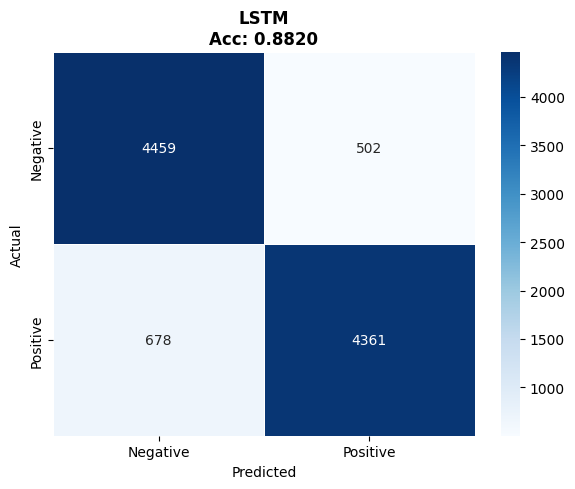

In [20]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Resultados da Classificação

In [22]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.87      0.90      0.88      4961
    Positive       0.90      0.87      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



# Exportação de Pesos

In [21]:
export_weights(lstm_model, mode='lstm', output_file="weights_lstm_big.mem")


print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO LSTM: Exportando pesos a partir da primeira LSTM
Ignorando: Embedding e SpatialDropout1D

Camada 0: LSTM
  addr=0x08000 Wx_candidate[0][0] = 0.243628
  addr=0x08001 Wx_candidate[0][1] = -0.009738
  addr=0x08080 Wx_candidate[1][0] = 0.356681
  addr=0x08081 Wx_candidate[1][1] = -0.232338
  addr=0x08040 Wh_candidate[0][0] = -0.098171
  addr=0x08041 Wh_candidate[0][1] = -0.051970
  addr=0x080C0 Wh_candidate[1][0] = -0.180388
  addr=0x080C1 Wh_candidate[1][1] = 0.189986
  addr=0x18000 bias_candidate[0] = 0.014196
  addr=0x18080 bias_candidate[1] = 0.077241
  addr=0x0A000 Wx_forget[0][0] = 0.381866
  addr=0x0A001 Wx_forget[0][1] = -0.388828
  addr=0x0A080 Wx_forget[1][0] = 0.120988
  addr=0x0A081 Wx_forget[1][1] = -0.365986
  addr=0x0A040 Wh_forget[0][0] = -0.239346
  addr=0x0A041 Wh_forget[0][1] = -0.036209
  addr=0x0A0C0 Wh_forget[1][0] = -0.046402
  addr=0x0A0C1 Wh_forget[1][1] = -0.208523
  addr=0x1A000 bias_forget[0] = 1.009561
  addr=0x1A080 bias_forget[1] = 1.059930
  addr=0x0C0

# Geração de teste único

In [22]:
texto_natural = "the was probaly the worst movie that I have seen"
texto_sem_stopwords = preprocess(texto_natural)
print(texto_sem_stopwords)

probaly worst movie seen


In [23]:
teste_qualquer = tokenizer.texts_to_sequences([texto_sem_stopwords])
teste_qualquer_pad = pad_sequences(teste_qualquer, maxlen=max_len)

In [24]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

x = teste_qualquer_pad

outputs = inspection_model.predict(x)

# salva em txt
with open("layer_outputs_simplified_model.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs_simplified_model.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Outputs salvos em layer_outputs_simplified_model.txt


# Teste Global

In [25]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

x = np.array([X_test_pad[0].tolist()])

outputs = inspection_model.predict(x)

# salva em txt
with open("Global Processing/layer_outputs_simplified_model.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs_simplified_model.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step
Outputs salvos em layer_outputs_simplified_model.txt


In [26]:
len(outputs[0][0])

120

In [27]:
FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q16(val):
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)


In [28]:
def export_matrix_to_mem(matrix,result,ground_result, output_file="matrix.mem"):
    mem = {}
    
    for linha_idx in range(matrix.shape[0]):
        for col_idx in range(4):
            addr = (linha_idx << 2) | col_idx
            valor = matrix[linha_idx, col_idx]
            valor_q16 = float_to_q16(valor)  # sua função original
            mem[addr] = valor_q16
    
    # ESCREVE EXATAMENTE COMO NO SEU CÓDIGO ORIGINAL
    with open(output_file, "w") as f:
        line = 0
        result_hex = float_to_q16(result)
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])  # ← igual ao original
            if line == 0:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X} {int(result_hex) & 0xFFFFFFFF:08X}  {int(ground_result) & 0xFFFFFFFF:01X}   \n")
            else:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
            line+=1
    print(f"Arquivo salvo: {output_file}")
    return mem

In [29]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)


for i in range(len(y_pred_lstm)):
    x = np.array([X_test_pad[i].tolist()])

    outputs = inspection_model.predict(x)
    
    export_matrix_to_mem(outputs[0][0], outputs[6][0][0], y_test.values[i], f"Global Processing/dados_{i}.mem")

    print(f"{i} de {len(y_pred_lstm)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 626ms/step
Arquivo salvo: Global Processing/dados_0.mem
0 de 10000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Arquivo salvo: Global Processing/dados_1.mem
1 de 10000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Arquivo salvo: Global Processing/dados_2.mem
2 de 10000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Arquivo salvo: Global Processing/dados_3.mem
3 de 10000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Arquivo salvo: Global Processing/dados_4.mem
4 de 10000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Arquivo salvo: Global Processing/dados_5.mem
5 de 10000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Arquivo salvo: Global Processing/dados_6.mem
6 de 10000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Arquivo salvo: Global Processing/dados_7.mem
7 de 10000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Arquivo salvo: Global Processing/dados_8.mem
8 de 10000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Arquivo salvo: Global Processing/dados_9.mem
9 de 10000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Arquivo salvo: Global